In [1]:
import os, sys, shutil, importlib

import src.helpers as H, src.feat as F, src.viz as V
import pytest

from pathlib import Path

We create this notebook in the Project Root dir in order to run the tests in the easies way!

In [2]:
# Ensure we're at the PROJECT ROOT (must contain src/ and tests/)
ROOT = Path.cwd()
if (ROOT / "notebooks").exists() and not (ROOT / "tests").exists():
    os.chdir("..")
    
ROOT = Path.cwd()

assert (ROOT / "src").exists(), "Project root must contain src/"
assert (ROOT / "tests").exists(), "Project root must contain tests/"

In [3]:
# Ensure src is a package and add root to sys.path for THIS process
(ROOT / "src" / "__init__.py").touch(exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [4]:
# Headless matplotlib for plots during tests
os.environ.setdefault("MPLBACKEND", "Agg")

'module://matplotlib_inline.backend_inline'

In [5]:
# Create/refresh a shared fixtures module and conftest for reliable imports/fixtures
(ROOT / "tests").mkdir(exist_ok=True)

In [6]:
# Shared fixture: df_min (touches helpers/feat/viz; first two rows duplicate for dedup tests)
(ROOT / "tests" / "fixtures.py").write_text(
    """import pandas as pd
import pytest

@pytest.fixture
def df_min():
    # first two rows are exact duplicates for dedup tests
    return pd.DataFrame({
        "PatientID":[1,1,2,3], "DoctorInCharge":["X","X","Y","Z"],
        "Age":[20,20,30,40], "BMI":[22.0,22.0,30.0,28.0],
        "PhysicalActivity":[0.3,0.3,0.2,0.9], "DietQuality":[6.0,6.0,4.0,7.0],
        "SleepQuality":[8.0,8.0,5.0,7.0], "PollutionExposure":[0.4,0.4,0.3,0.9],
        "PollenExposure":[0.5,0.5,0.2,0.8], "DustExposure":[0.4,0.4,0.3,0.7],
        "LungFunctionFEV1":[3.0,3.0,2.5,3.5], "LungFunctionFVC":[3.2,3.2,2.6,3.6],
        "Gender":[1,1,0,1], "Ethnicity":[1,1,2,3], "EducationLevel":[1,1,2,3],
        "Smoking":[0,0,1,1], "PetAllergy":[1,1,0,1], "FamilyHistoryAsthma":[1,1,0,1],
        "HistoryOfAllergies":[0,0,1,0], "Eczema":[1,1,0,1], "HayFever":[0,0,1,0],
        "GastroesophagealReflux":[1,1,0,1], "Wheezing":[1,1,0,1],
        "ShortnessOfBreath":[1,1,1,0], "ChestTightness":[1,1,0,1],
        "Coughing":[1,1,0,1], "NighttimeSymptoms":[0,0,1,1], "ExerciseInduced":[1,1,0,1],
        "Diagnosis":[1,1,0,0], "CONST":[5,5,5,5], "AgeCopy":[20,20,30,40],
    })
""",
    encoding="utf-8",
)

1147

In [7]:
# Conftest: add project root to sys.path and register fixtures plugin
(ROOT / "tests" / "conftest.py").write_text(
    """import sys, pathlib, os
ROOT = pathlib.Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLBACKEND", "Agg")
pytest_plugins = ["tests.fixtures"]
""",
    encoding="utf-8",
)

218

In [8]:
# Nuke caches
for p in [ROOT / ".pytest_cache", *ROOT.rglob("__pycache__")]:
    shutil.rmtree(p, ignore_errors=True)

In [9]:
# Install pytest + hypothesis (Jupyter-safe)
try:
    get_ipython().run_line_magic("pip", "install -q -U pytest hypothesis")
except Exception:
    os.system(f'"{sys.executable}" -m pip install -q -U pytest hypothesis')

Note: you may need to restart the kernel to use updated packages.



--- Pytest start ---

............

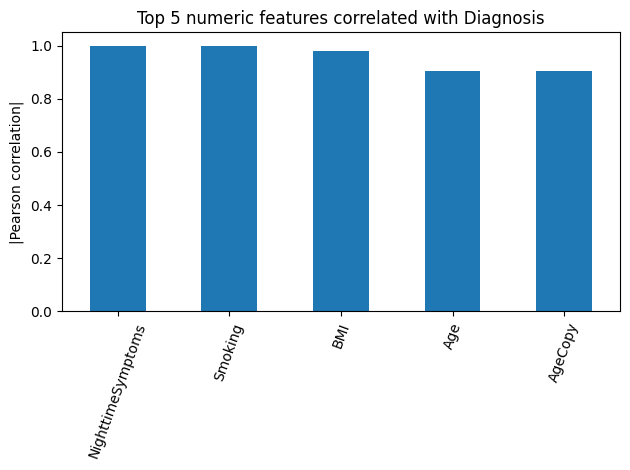

.                                                                                                    [100%]
13 passed in 1.84s

--- Pytest end (exit code: 0 ) ---


In [10]:
# Run ALL tests in-process so pathing stays fixed; show concise result
print("\n--- Pytest start ---\n")
exit_code = pytest.main(["-q", "--cache-clear"])
print("\n--- Pytest end (exit code:", exit_code, ") ---")